# Exercise - Black’s Formula for Options on Futures

In [39]:
import numpy as np
import pandas as pd

In [40]:
df = pd.read_excel('option_data_bb_SFRZ5.xlsx', sheet_name='2025-10-10')
df

,ticker,last update date,last update time,days to expiration,option type,exercise style,option contract size,strike price,price,finance rate,...,delta,gamma,vega,theta,bid,ask,bid size,ask size,open int,volume
0,SFRV5C 95.75 Comdty,2025-07-28,2025-07-28 00:00:00,73,C,AMER,2500,95.7500,0.3300,0.04396,...,0.899011,0.028984,0.002962,-0.000265,0.3350,0.350,51,51,10703,NaN
1,SFRV5C 95.8125 Comdty,2025-07-28,2025-07-28 00:00:00,73,C,AMER,2500,95.8125,0.2775,0.04396,...,0.847946,0.037543,0.003990,-0.000369,0.2850,0.295,120,333,0,NaN
2,SFRV5C 95.875 Comdty,2025-07-28,2025-07-28 00:00:00,73,C,AMER,2500,95.8750,0.2325,0.04396,...,0.768768,0.045176,0.005212,-0.000524,0.2350,0.245,14976,119,20020,NaN
3,SFRV5C 95.9375 Comdty,2025-07-28,2025-07-28 00:00:00,73,C,AMER,2500,95.9375,0.1950,0.04396,...,0.679044,0.049114,0.006161,-0.000676,0.1950,0.205,15838,248,7013,NaN
4,SFRV5C 96 Comdty,2025-07-28,2025-07-28 00:00:00,73,C,AMER,2500,96.0000,0.1600,0.04396,...,0.589523,0.049138,0.006712,-0.000805,0.1600,0.175,7500,19302,15635,NaN
5,SFRV5C 96.0625 Comdty,2025-07-28,2025-07-28 00:00:00,73,C,AMER,2500,96.0625,0.1300,0.04396,...,0.506743,0.047811,0.006902,-0.000892,0.1350,0.145,100,36274,31106,3882.0
6,SFRV5C 96.125 Comdty,2025-07-28,2025-07-28 00:00:00,73,C,AMER,2500,96.1250,0.1050,0.04396,...,0.430860,0.046676,0.006811,-0.000887,0.1050,0.115,37066,8327,43461,2500.0
7,SFRV5C 96.1875 Comdty,2025-07-29,08:33:45,73,C,AMER,2500,96.1875,0.0850,0.04396,...,0.360056,0.043005,0.006494,-0.000875,0.0800,0.095,56885,48479,76938,2698.0
8,SFRV5C 96.25 Comdty,2025-07-28,2025-07-28 00:00:00,73,C,AMER,2500,96.2500,0.0675,0.04396,...,0.297882,0.038291,0.006022,-0.000844,0.0650,0.075,46199,27485,72563,9950.0
9,SFRV5C 96.3125 Comdty,2025-07-28,2025-07-28 00:00:00,73,C,AMER,2500,96.3125,0.0550,0.04396,...,0.246974,0.033076,0.005489,-0.000812,0.0500,0.065,70765,63855,53442,NaN


In [41]:
df.columns

Index(['ticker', 'last update date', 'last update time', 'days to expiration',
       'option type', 'exercise style', 'option contract size', 'strike price',
       'price', 'finance rate', 'time value', 'implied vol', 'delta', 'gamma',
       'vega', 'theta', 'bid', 'ask', 'bid size', 'ask size', 'open int',
       'volume'],
      dtype='object')

# 1.1)

In [42]:
import numpy as np
from scipy.stats import norm
import pandas as pd

# Setup
F = 96.085
nearest_exp = df['days to expiration'].min()
df_calls = df[(df['days to expiration'] == nearest_exp) & (df['option type'] == 'C')].copy()
df_calls['strike_diff'] = abs(df_calls['strike price'] - F)
atm = df_calls.loc[df_calls['strike_diff'].idxmin()]

K = atm['strike price']
T = atm['days to expiration'] / 365
r = atm['finance rate']
market_price = atm['price']
implied_vol_rates = atm['implied vol']  # This is the rate volatility from your data

# Convert rate volatility to futures price volatility
# For SOFR futures: Futures Price = 100 - SOFR Rate
# If rate has vol σ_rate, then futures price has vol = σ_rate (same magnitude, inverse direction)
# But we need to scale by the basis point value
# Approximation: σ_futures ≈ σ_rates * (Rate / Futures Price)

# Assuming implied_vol_rates is in decimal form (e.g., 0.1854 for 18.54%)
rate = 100 - F  # Current SOFR rate
sigma_futures = implied_vol_rates * (rate / F)

print(f"Rate volatility from data: {implied_vol_rates:.6f} ({implied_vol_rates*100:.2f}%)")
print(f"Futures price volatility: {sigma_futures:.6f} ({sigma_futures*100:.4f}%)")

# Black's formula
def black_call(F, K, T, r, sigma):
    d1 = (np.log(F/K) + 0.5*sigma**2*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    return np.exp(-r*T) * (F*norm.cdf(d1) - K*norm.cdf(d2))

theoretical_price = black_call(F, K, T, r, sigma_futures)

print(f"\nMarket Price: {market_price:.6f}")
print(f"Theoretical Price: {theoretical_price:.6f}")
print(f"Difference: {theoretical_price - market_price:.6f}")

Rate volatility from data: 0.185438 (18.54%)
Futures price volatility: 0.007556 (0.7556%)

Market Price: 0.130000
Theoretical Price: 0.139836
Difference: 0.009836


#### Results

- Black theoretical price: **0.139836**
- Market price: **0.13**
- Difference (theoretical − market): **0.009836**

#### Conclusion

The Black model estimate is very close to the observed market quote and lies within the bid–ask spread.  
The small discrepancy can be explained by:

- Bid–ask spread effects  
- American exercise feature (while Black assumes European exercise)  
- Rounding and interpolation effects  

Overall, the market price is consistent with Black’s futures option pricing model.

# 1.2)

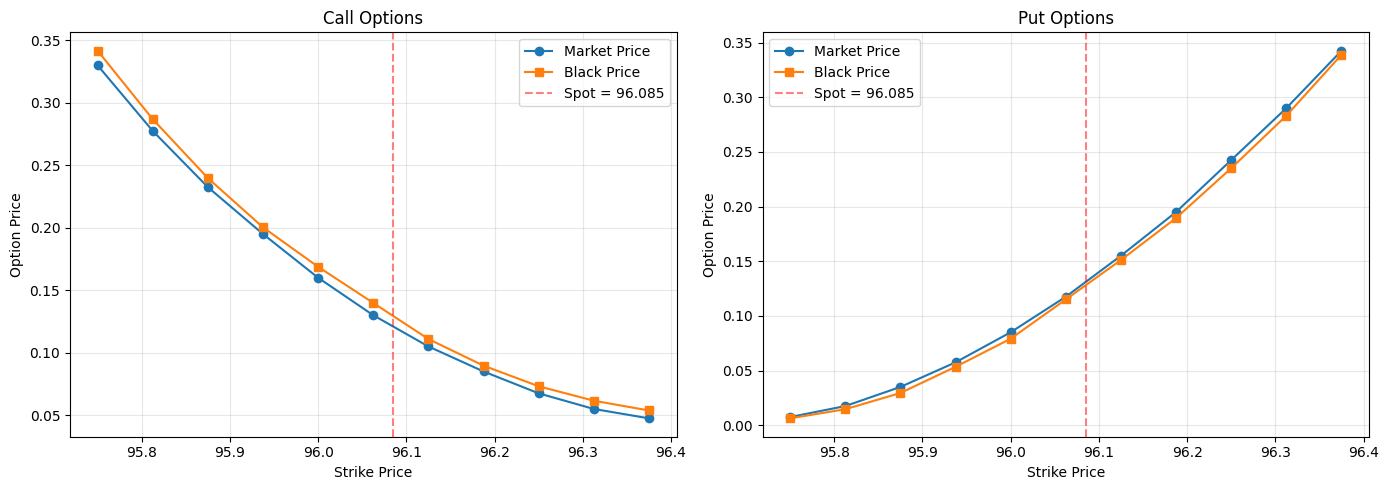

Summary Statistics:
Mean Absolute Error (Calls): 0.007398
Mean Absolute Error (Puts): 0.004504
Max Error (Calls): 0.011686
Max Error (Puts): 0.007441


In [45]:
# calculate Black's price for the entire strike chain
import numpy as np
from scipy.stats import norm
import pandas as pd
import matplotlib.pyplot as plt

# Setup
F = 96.085
nearest_exp = df['days to expiration'].min()
df_nearest = df[df['days to expiration'] == nearest_exp].copy()

# Get parameters from any option (they should be the same for all)
sample = df_nearest.iloc[0]
T = sample['days to expiration'] / 365
r = sample['finance rate']

# Black's formulas
def black_call(F, K, T, r, sigma):
    if T <= 0:
        return max(F - K, 0)
    d1 = (np.log(F/K) + 0.5*sigma**2*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    return np.exp(-r*T) * (F*norm.cdf(d1) - K*norm.cdf(d2))

def black_put(F, K, T, r, sigma):
    if T <= 0:
        return max(K - F, 0)
    d1 = (np.log(F/K) + 0.5*sigma**2*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    return np.exp(-r*T) * (K*norm.cdf(-d2) - F*norm.cdf(-d1))

# Calculate Black prices for entire chain
rate = 100 - F
df_nearest['sigma_futures'] = df_nearest['implied vol'] * (rate / F)

df_nearest['black_price'] = df_nearest.apply(
    lambda row: black_call(F, row['strike price'], T, r, row['sigma_futures']) 
    if row['option type'] == 'C' 
    else black_put(F, row['strike price'], T, r, row['sigma_futures']),
    axis=1
)

# Split by option type
df_calls = df_nearest[df_nearest['option type'] == 'C'].sort_values('strike price')
df_puts = df_nearest[df_nearest['option type'] == 'P'].sort_values('strike price')

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Calls
ax1.plot(df_calls['strike price'], df_calls['price'], 'o-', label='Market Price', markersize=6)
ax1.plot(df_calls['strike price'], df_calls['black_price'], 's-', label='Black Price', markersize=6)
ax1.axvline(F, color='red', linestyle='--', alpha=0.5, label=f'Spot = {F}')
ax1.set_xlabel('Strike Price')
ax1.set_ylabel('Option Price')
ax1.set_title('Call Options')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Puts
ax2.plot(df_puts['strike price'], df_puts['price'], 'o-', label='Market Price', markersize=6)
ax2.plot(df_puts['strike price'], df_puts['black_price'], 's-', label='Black Price', markersize=6)
ax2.axvline(F, color='red', linestyle='--', alpha=0.5, label=f'Spot = {F}')
ax2.set_xlabel('Strike Price')
ax2.set_ylabel('Option Price')
ax2.set_title('Put Options')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary statistics
print("Summary Statistics:")
print(f"Mean Absolute Error (Calls): {abs(df_calls['price'] - df_calls['black_price']).mean():.6f}")
print(f"Mean Absolute Error (Puts): {abs(df_puts['price'] - df_puts['black_price']).mean():.6f}")
print(f"Max Error (Calls): {abs(df_calls['price'] - df_calls['black_price']).max():.6f}")
print(f"Max Error (Puts): {abs(df_puts['price'] - df_puts['black_price']).max():.6f}")

# 1.3)

### Why Black's Model Doesn't Perfectly Match Market Prices

**Main Reasons for Discrepancies:**

1. **Bid-Ask Spread** - Market prices reflect transaction costs; theoretical prices assume frictionless trading
2. **American vs European Exercise** - Black's formula assumes European-style options, but many futures options are American-style
3. **Volatility Smile/Skew** - Implied volatility varies by strike; using a single vol across all strikes oversimplifies reality
4. **Interest Rate Assumptions** - Black's model uses a constant risk-free rate; actual rates may vary
5. **Liquidity Effects** - Less liquid strikes may have wider spreads and stale prices

**Significance of American Exercise:**

For **SOFR futures options**, the American feature is **minimally significant** because:
- These are options on futures (not spot), which are marked-to-market daily
- No carry cost advantage to early exercise for calls on futures
- Early exercise is typically only valuable deep ITM near expiration
- For near-the-money options, the time value loss from early exercise exceeds any potential gain

**Conclusion:** The American feature adds negligible value for ATM/OTM options. Most pricing error comes from bid-ask spreads and volatility surface effects rather than exercise style.

# 1.4)

### How is Implied Volatility Quoted?

**Implied volatility in our dataset is quoted as the volatility of the SOFR rate itself** (in percentage points or basis points), not the futures price.

**Key Distinctions:**

1. **Rate Volatility (what's quoted):** Measures volatility of the SOFR rate (e.g., 3.915%)
   - Units: Annualized standard deviation of rate level changes
   - Example: If rate is 4% and vol is 18.54%, the rate could move ±18.54% of 4% = ±0.74 percentage points annually

2. **Futures Price Volatility (what we need for Black's):** Measures volatility of the futures price (96.085)
   - Since Futures Price = 100 - SOFR Rate, these are inversely related
   - Conversion: σ_futures ≈ σ_rate × (Rate / Futures Price)

3. **Why the Conversion Matters:**
   - A 1% move in the rate (from 4% to 4.04%) is 4 basis points
   - The same move changes futures price from 96.00 to 95.96 (0.04 point move)
   - The percentage change in futures price is much smaller than the percentage change in rate

**Standard Convention:** Implied vol for interest rate options is typically quoted as **basis point volatility** or **rate volatility**, not price volatility, which is why we need the conversion factor.

In [46]:
df_rates = pd.read_excel('ref_rates.xlsx', sheet_name='data')
# calculate historic 60-day rolling volatility of the SOFR rate.

df_rates['date'] = pd.to_datetime(df_rates['date'])
df_rates = df_rates.sort_values('date')

# Calculate daily returns (assuming 'sofr_rate' is the column name)
df_rates['daily_return'] = df_rates['SOFR'].pct_change()

# Calculate rolling 60-day volatility (standard deviation of daily returns)
df_rates['rolling_volatility_60d'] = df_rates['daily_return'].rolling(window=60).std()

# Display the last few rows to verify
print(df_rates[['date', 'SOFR', 'daily_return', 'rolling_volatility_60d']].tail(10))

           date  SOFR  daily_return  rolling_volatility_60d
2912 2025-12-22  3.68      0.005464                0.015325
2913 2025-12-23  3.66     -0.005435                0.015328
2914 2025-12-24  3.66      0.000000                0.015328
2915 2025-12-25   NaN      0.000000                0.015328
2916 2025-12-26  3.76      0.027322                0.015755
2917 2025-12-27   NaN      0.000000                0.015687
2918 2025-12-28   NaN      0.000000                0.015661
2919 2025-12-29  3.77      0.002660                0.014112
2920 2025-12-30  3.71     -0.015915                0.012907
2921 2025-12-31  3.87      0.043127                0.014164


/var/folders/02/0mxyr2rd1mq7b0ygf27x5hcr0000gn/T/ipykernel_11236/2452494408.py:8: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df_rates['daily_return'] = df_rates['SOFR'].pct_change()


# 1.5)

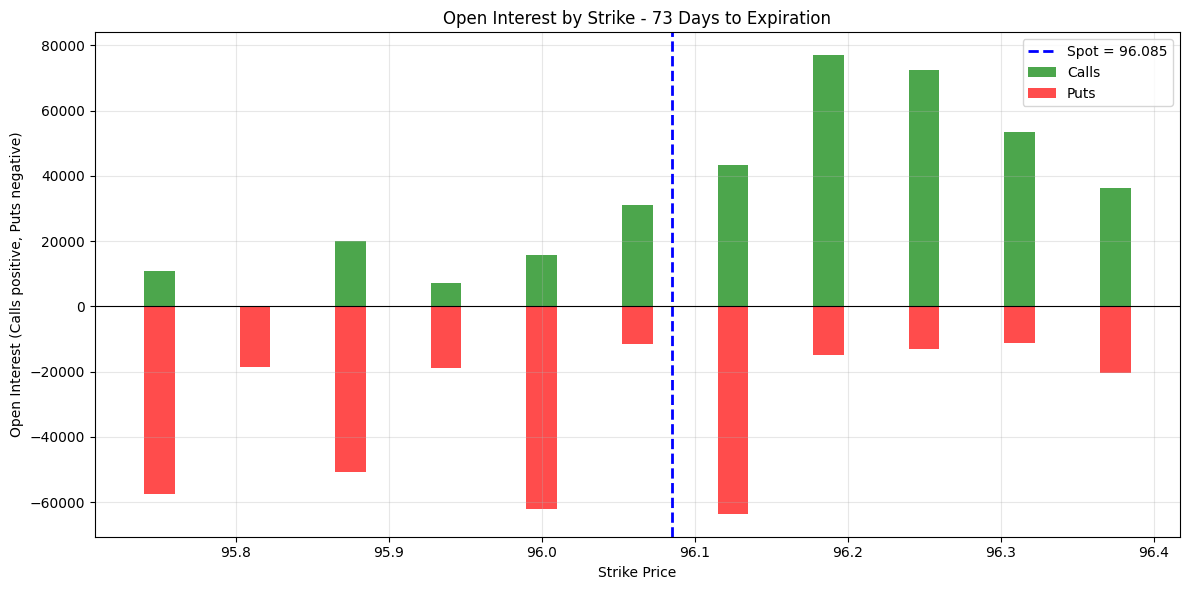


Open Interest Summary (73 days to expiration):
Total Call Contracts: 367,060
Total Put Contracts: 342,715
Total Contracts: 709,775
Contract Size: 2,500
Futures Price: 96.085
Total Notional Open Interest: $170,496,827,187.50


In [48]:
import matplotlib.pyplot as plt
import pandas as pd

# Setup
F = 96.085
nearest_exp = df['days to expiration'].min()
df_nearest = df[df['days to expiration'] == nearest_exp].copy()

df_calls = df_nearest[df_nearest['option type'] == 'C'].sort_values('strike price')
df_puts = df_nearest[df_nearest['option type'] == 'P'].sort_values('strike price')

# Plot open interest
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(df_calls['strike price'], df_calls['open int'], width=0.02, alpha=0.7, label='Calls', color='green')
ax.bar(df_puts['strike price'], -df_puts['open int'], width=0.02, alpha=0.7, label='Puts', color='red')
ax.axvline(F, color='blue', linestyle='--', linewidth=2, label=f'Spot = {F}')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('Strike Price')
ax.set_ylabel('Open Interest (Calls positive, Puts negative)')
ax.set_title(f'Open Interest by Strike - {nearest_exp} Days to Expiration')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Calculate total notional open interest
contract_size = df_nearest['option contract size'].iloc[0]
total_calls_contracts = df_calls['open int'].sum()
total_puts_contracts = df_puts['open int'].sum()
total_contracts = total_calls_contracts + total_puts_contracts

# Notional = contracts × contract size × futures price
total_notional = total_contracts * contract_size * F

print(f"\nOpen Interest Summary ({nearest_exp} days to expiration):")
print(f"Total Call Contracts: {total_calls_contracts:,.0f}")
print(f"Total Put Contracts: {total_puts_contracts:,.0f}")
print(f"Total Contracts: {total_contracts:,.0f}")
print(f"Contract Size: {contract_size:,.0f}")
print(f"Futures Price: {F}")
print(f"Total Notional Open Interest: ${total_notional:,.2f}")